# Exploratory Data Analysis: Home Credit repayment difficulty

**Course project:** Home Credit Default Risk  
**Data used:** `application_train.csv` and `application_test.csv`  
**Outcome:** `TARGET = 1` indicates a client with payment difficulty.

## Table of contents

1. [Business problem and analytic questions](#Business-problem-and-analytic-questions)
2. [Data and analytic approach](#Data-and-analytic-approach)
3. [Data integrity checks](#Data-integrity-checks)
4. [Exploratory results](#Exploratory-results)
5. [Modeling, governance, and decision implications](#Modeling-governance-and-decision-implications)
6. [Results and next steps](#Results-and-next-steps)
7. [AI-use statement](#AI-use-statement)

This notebook is an exploratory, not causal, analysis. Observed payment-difficulty rates identify associations in issued loans; they do not prove that a characteristic causes repayment difficulty or justify an automated lending decision by itself.

## Business problem and analytic questions

Home Credit needs to identify applications whose repayment difficulty is more likely while avoiding avoidable declines of applicants who can repay. The immediate analytic task is to understand the labeled application population, establish which fields are usable at application time, and identify patterns that should be tested in a later predictive model.

The guiding questions are:

1. How frequent and imbalanced is payment difficulty?
2. Do the application tables have unique keys, compatible train/test schemas, and usable category levels?
3. Which fields are missing, implausible, or potentially misleading—and what defensible treatment should follow?
4. How do affordability measures and applicant characteristics relate to observed difficulty?
5. Which patterns should inform modeling, validation, fairness review, and additional data collection?

## Data and analytic approach

In [1]:
# Load only the two application-level files required for this assignment.
# Warnings are suppressed so the rendered report stays readable; data issues are checked explicitly below.
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
ROOT = next(p for p in candidate_roots if (p / "data" / "raw").exists())
RAW = ROOT / "data" / "raw"

train = pd.read_csv(RAW / "application_train.csv")
test = pd.read_csv(RAW / "application_test.csv")
dictionary = pd.read_csv(RAW / "HomeCredit_columns_description.csv", encoding="latin1")

print(
    f"Loaded {len(train):,} labeled training applications and {len(test):,} test applications."
)

Loaded 307,511 labeled training applications and 48,744 test applications.


In [2]:
# Summarize the two application tables before exploring individual variables.
table_summary = pd.DataFrame(
    {
        "rows": [len(train), len(test)],
        "columns": [train.shape[1], test.shape[1]],
        "unique_application_ids": [
            train.SK_ID_CURR.nunique(),
            test.SK_ID_CURR.nunique(),
        ],
    },
    index=["training", "test"],
)
display(table_summary)

column_groups = pd.DataFrame(
    {
        "group": ["identifier", "target", "numeric", "categorical"],
        "training_columns": [
            1,
            1,
            train.select_dtypes(include="number").shape[1] - 2,
            train.select_dtypes(exclude="number").shape[1],
        ],
        "meaning": [
            "application key",
            "observed repayment outcome",
            "amounts, counts, flags, relative dates",
            "application categories",
        ],
    }
)
display(column_groups)

,rows,columns,unique_application_ids
training,307511,122,307511
test,48744,121,48744


,group,training_columns,meaning
0,identifier,1,application key
1,target,1,observed repayment outcome
2,numeric,104,"amounts, counts, flags, relative dates"
3,categorical,16,application categories


The training file contains 307,511 issued-loan applications and 122 columns; the test file contains 48,744 applications and the same application features without `TARGET`. `SK_ID_CURR` is the application key. The fields mix applicant-provided information, external-source scores, process flags, and relative-date variables. Those different sources matter: a field may predict well while still being unusable, unstable, or inappropriate for a lending decision.

The data dictionary documents the columns, but it does not by itself establish when every value became available. It also does not provide source-system lineage or a complete explanation of every special value. Therefore, this EDA treats application fields as candidates for later review rather than declaring them automatically eligible for production use.

## Data integrity checks

### 1. Is the outcome rare enough to require an imbalance-aware evaluation?

,applications,share
TARGET,,
No payment difficulty,282686,0.919
Payment difficulty,24825,0.081


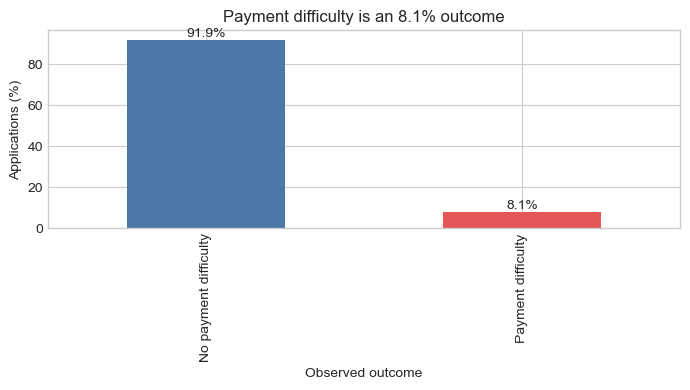

In [3]:
# Count the labeled outcomes and make the class imbalance visible.
target_counts = (
    train.TARGET.value_counts()
    .sort_index()
    .rename(index={0: "No payment difficulty", 1: "Payment difficulty"})
)
target_table = pd.DataFrame(
    {"applications": target_counts, "share": target_counts / len(train)}
)
display(target_table)

ax = (target_table["share"] * 100).plot.bar(
    color=["#4C78A8", "#E45756"], figsize=(7, 4)
)
ax.set(
    title="Payment difficulty is an 8.1% outcome",
    xlabel="Observed outcome",
    ylabel="Applications (%)",
)
ax.bar_label(ax.containers[0], fmt="%.1f%%")
plt.tight_layout()
plt.show()

Payment difficulty occurs for **8.1%** of the labeled applications (24,825 of 307,511). A model that predicts no difficulty for everyone would appear 91.9% accurate while failing to identify any difficult cases. Later modeling should therefore emphasize discrimination and calibration measures suited to imbalance—such as ROC-AUC, precision-recall AUC, recall at a business-selected review capacity, and calibrated risk—not accuracy alone. Resampling or class weights should be fitted within each training fold only.

### 2. Are application keys unique and are train/test features compatible?

In [4]:
# Test application-key uniqueness and compare feature availability across the two splits.
key_check = pd.DataFrame(
    {
        "rows": [len(train), len(test)],
        "unique_SK_ID_CURR": [train.SK_ID_CURR.nunique(), test.SK_ID_CURR.nunique()],
        "duplicate_full_rows": [train.duplicated().sum(), test.duplicated().sum()],
    },
    index=["training", "test"],
)
display(key_check)

train_features = set(train.columns) - {"TARGET"}
test_features = set(test.columns)
schema_check = pd.DataFrame(
    {
        "check": [
            "train-only features",
            "test-only features",
            "shared features with different dtype",
        ],
        "count": [
            len(train_features - test_features),
            len(test_features - train_features),
            sum(
                train[c].dtype != test[c].dtype for c in train_features & test_features
            ),
        ],
    }
)
display(schema_check)

cat_cols = train.select_dtypes(include="object").columns
level_check = pd.DataFrame(
    {
        "field": cat_cols,
        "train_only_levels": [
            len(set(train[c].dropna()) - set(test[c].dropna())) for c in cat_cols
        ],
        "test_only_levels": [
            len(set(test[c].dropna()) - set(train[c].dropna())) for c in cat_cols
        ],
    }
)
display(level_check.query("train_only_levels > 0 or test_only_levels > 0"))

,rows,unique_SK_ID_CURR,duplicate_full_rows
training,307511,307511,0
test,48744,48744,0


,check,count
0,train-only features,0
1,test-only features,0
2,shared features with different dtype,0


,field,train_only_levels,test_only_levels
1,CODE_GENDER,1,0
5,NAME_INCOME_TYPE,1,0
7,NAME_FAMILY_STATUS,1,0


Every `SK_ID_CURR` value is unique within each split, and there are no fully duplicated rows. The test set differs only by the absence of `TARGET`, and shared feature data types match. A few rare category levels occur in training but not test; any encoder must tolerate unseen or absent levels and should consolidate extremely sparse categories only after checking that doing so does not conceal a meaningful group. There is no customer-level key, so this file cannot establish whether multiple applications belong to the same person.

### 3. Which fields are missing, and is missingness associated with the outcome?

,overall_missing_pct,no_difficulty_missing_pct,difficulty_missing_pct,difference_pct_points
COMMONAREA_MEDI,69.872,69.491,74.211,4.720
COMMONAREA_AVG,69.872,69.491,74.211,4.720
COMMONAREA_MODE,69.872,69.491,74.211,4.720
NONLIVINGAPARTMENTS_MODE,69.433,69.047,73.825,4.777
NONLIVINGAPARTMENTS_AVG,69.433,69.047,73.825,4.777
NONLIVINGAPARTMENTS_MEDI,69.433,69.047,73.825,4.777
FONDKAPREMONT_MODE,68.386,67.980,73.011,5.031
LIVINGAPARTMENTS_MODE,68.355,67.947,72.999,5.052
LIVINGAPARTMENTS_AVG,68.355,67.947,72.999,5.052
LIVINGAPARTMENTS_MEDI,68.355,67.947,72.999,5.052


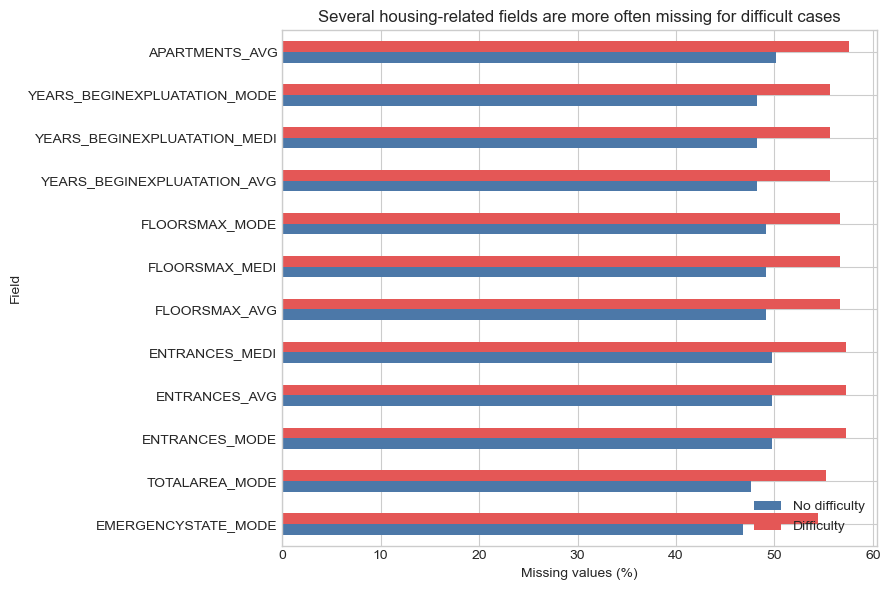

In [5]:
# Compare missingness rates overall and by outcome; display the largest target differences.
missing = pd.DataFrame(
    {
        "overall_missing_pct": train.isna().mean() * 100,
        "no_difficulty_missing_pct": train.loc[train.TARGET.eq(0)].isna().mean() * 100,
        "difficulty_missing_pct": train.loc[train.TARGET.eq(1)].isna().mean() * 100,
    }
)
missing["difference_pct_points"] = (
    missing["difficulty_missing_pct"] - missing["no_difficulty_missing_pct"]
)
top_missing = missing.sort_values("overall_missing_pct", ascending=False).head(15)
display(top_missing)

plot_missing = missing.reindex(
    missing.difference_pct_points.abs().sort_values(ascending=False).head(12).index
)
ax = plot_missing[["no_difficulty_missing_pct", "difficulty_missing_pct"]].plot.barh(
    figsize=(9, 6), color=["#4C78A8", "#E45756"]
)
ax.set(
    title="Several housing-related fields are more often missing for difficult cases",
    xlabel="Missing values (%)",
    ylabel="Field",
)
ax.legend(["No difficulty", "Difficulty"])
plt.tight_layout()
plt.show()

Missingness is substantial in external-source and housing/building fields. For example, `EXT_SOURCE_1` is missing for 56.4% of training applications. Several building-related fields have roughly 7.2–7.6 percentage points more missingness among payment-difficulty cases; `EMERGENCYSTATE_MODE` is missing for 54.4% of difficult cases versus 46.8% of non-difficult cases. This makes a simple “fill every blank with the median” treatment inadequate. The modeling pipeline should retain missing-value indicators, impute numeric and categorical fields within folds, and compare performance with and without high-missingness groups. Missingness may encode data-collection or access differences, so it also warrants group-level fairness review.

### 4. Are there sentinel or impossible values?

In [6]:
# Identify the well-known employment sentinel and inspect relative-day fields.
day_columns = [c for c in train.columns if c.startswith("DAYS_")]
day_check = pd.DataFrame(
    {
        "positive_values": [(train[c] > 0).sum() for c in day_columns],
        "sentinel_365243": [(train[c] == 365243).sum() for c in day_columns],
        "minimum": [train[c].min() for c in day_columns],
        "maximum": [train[c].max() for c in day_columns],
    },
    index=day_columns,
)
display(day_check)

sentinel_by_target = (
    train.assign(employment_sentinel=train.DAYS_EMPLOYED.eq(365243))
    .groupby("employment_sentinel")
    .TARGET.agg(["count", "mean"])
)
display(sentinel_by_target)

,positive_values,sentinel_365243,minimum,maximum
DAYS_BIRTH,0,0,"-25,229.000","-7,489.000"
DAYS_EMPLOYED,55374,55374,"-17,912.000","365,243.000"
DAYS_REGISTRATION,0,0,"-24,672.000",0.000
DAYS_ID_PUBLISH,0,0,"-7,197.000",0.000
DAYS_LAST_PHONE_CHANGE,0,0,"-4,292.000",0.000


,count,mean
employment_sentinel,,
False,252137,0.087
True,55374,0.054


`DAYS_EMPLOYED` contains 55,374 values of 365,243, a positive number incompatible with the documented “days before application” interpretation. This is a sentinel, not a plausible employment duration. It should be replaced with missing *and* accompanied by an `employment_sentinel` indicator, because the sentinel group has a distinct observed rate. The other relative-day fields are non-positive as expected. Small numbers of zeros in registration and ID-publication fields should be retained as potentially valid boundary values unless the data owner confirms otherwise. Raw columns are not overwritten in this notebook.

### 5. Are financial values plausible, and where are the extremes?

,count,mean,std,min,1%,50%,99%,max,zero_count
AMT_INCOME_TOTAL,"307,511.000","168,797.919","237,123.146","25,650.000","45,000.000","147,150.000","472,500.000","117,000,000.000",0
AMT_CREDIT,"307,511.000","599,026.000","402,490.777","45,000.000","76,410.000","513,531.000","1,854,000.000","4,050,000.000",0
AMT_ANNUITY,"307,499.000","27,108.574","14,493.737","1,615.500","6,182.910","24,903.000","70,006.500","258,025.500",0
AMT_GOODS_PRICE,"307,233.000","538,396.207","369,446.461","40,500.000","67,500.000","450,000.000","1,800,000.000","4,050,000.000",0


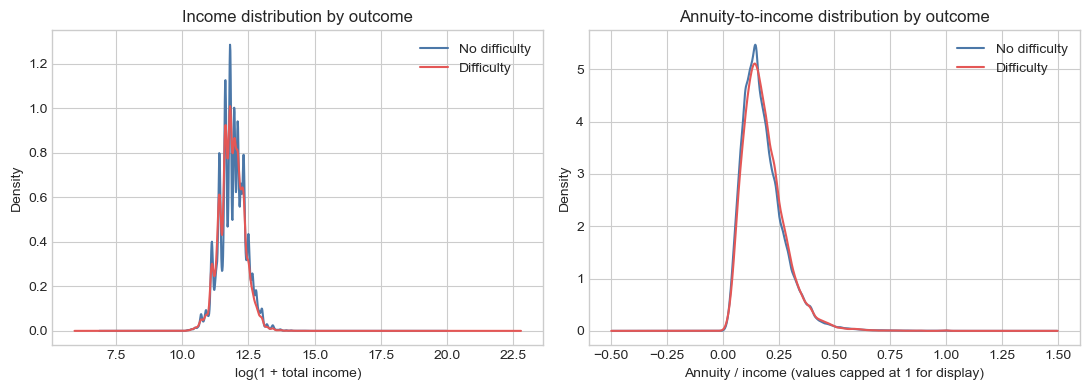

In [7]:
# Summarize the primary monetary variables and visualize income on a robust scale.
money = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]
money_summary = train[money].describe(percentiles=[0.01, 0.50, 0.99]).T
money_summary["zero_count"] = (train[money] == 0).sum()
display(money_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for target, color, label in [
    (0, "#4C78A8", "No difficulty"),
    (1, "#E45756", "Difficulty"),
]:
    np.log1p(train.loc[train.TARGET.eq(target), "AMT_INCOME_TOTAL"]).plot.kde(
        ax=axes[0], color=color, label=label
    )
    (
        train.loc[train.TARGET.eq(target), "AMT_ANNUITY"]
        / train.loc[train.TARGET.eq(target), "AMT_INCOME_TOTAL"]
    ).clip(upper=1).plot.kde(ax=axes[1], color=color, label=label)
axes[0].set(
    title="Income distribution by outcome",
    xlabel="log(1 + total income)",
    ylabel="Density",
)
axes[1].set(
    title="Annuity-to-income distribution by outcome",
    xlabel="Annuity / income (values capped at 1 for display)",
    ylabel="Density",
)
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

The monetary amounts are non-negative and mostly plausible, but income has a very long right tail (99th percentile: 472,500; maximum: 117,000,000). That maximum should be flagged for review rather than silently deleted or globally capped. A robust transformation such as `log1p(income)` and fold-fitted winsorization sensitivity checks are reasonable modeling experiments. Applicants with payment difficulty have lower median income (135,000 versus 148,500) and slightly higher median annuity (25,263 versus 24,876), while median credit-to-income ratios are similar. The plots suggest affordability is not a one-variable problem; loan burden should be modeled with income, credit, annuity, household context, and nonlinear effects together.

## Exploratory results

### 6. How do age, education, income source, and housing relate to observed difficulty?

,applications,difficulty_rate
age_band,,
"(20, 30]",45186,0.114
"(30, 40]",82349,0.096
"(40, 50]",76581,0.076
"(50, 60]",68109,0.061
"(60, 100]",35286,0.049


,applications,difficulty_rate
NAME_EDUCATION_TYPE,,
Lower secondary,3816,0.109
Secondary / secondary special,218391,0.089
Incomplete higher,10277,0.085
Higher education,74863,0.054
Academic degree,164,0.018


,applications,difficulty_rate
NAME_INCOME_TYPE,,
Maternity leave,5,0.400
Unemployed,22,0.364
Working,158774,0.096
Commercial associate,71617,0.075
State servant,21703,0.058
Pensioner,55362,0.054
Businessman,10,0.000
Student,18,0.000


,applications,difficulty_rate
NAME_HOUSING_TYPE,,
Rented apartment,4881,0.123
With parents,14840,0.117
Municipal apartment,11183,0.085
Co-op apartment,1122,0.079
House / apartment,272868,0.078
Office apartment,2617,0.066


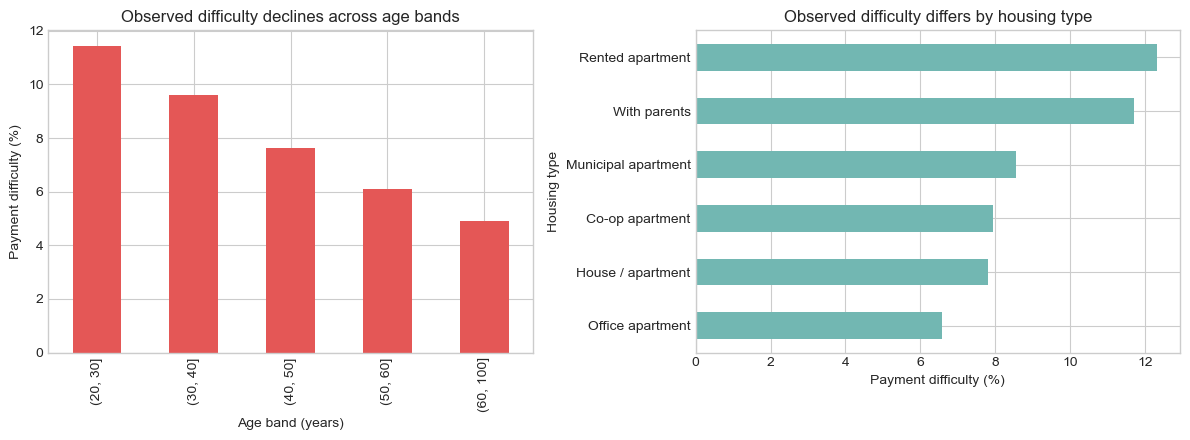

In [8]:
# Create interpretable age bands and calculate outcome rates for selected applicant characteristics.
eda = train.assign(
    age_years=-train.DAYS_BIRTH / 365.25,
    age_band=pd.cut(-train.DAYS_BIRTH / 365.25, [20, 30, 40, 50, 60, 100], right=True),
)


def outcome_rates(frame, field):
    return (
        frame.groupby(field, dropna=False, observed=False)
        .TARGET.agg(applications="size", difficulty_rate="mean")
        .sort_values("difficulty_rate", ascending=False)
    )


age_rates = outcome_rates(eda, "age_band")
education_rates = outcome_rates(eda, "NAME_EDUCATION_TYPE")
income_rates = outcome_rates(eda, "NAME_INCOME_TYPE")
housing_rates = outcome_rates(eda, "NAME_HOUSING_TYPE")
display(age_rates)
display(education_rates)
display(income_rates)
display(housing_rates)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
(age_rates.difficulty_rate * 100).plot.bar(ax=axes[0], color="#E45756")
axes[0].set(
    title="Observed difficulty declines across age bands",
    xlabel="Age band (years)",
    ylabel="Payment difficulty (%)",
)
(housing_rates.difficulty_rate * 100).sort_values().plot.barh(
    ax=axes[1], color="#72B7B2"
)
axes[1].set(
    title="Observed difficulty differs by housing type",
    xlabel="Payment difficulty (%)",
    ylabel="Housing type",
)
plt.tight_layout()
plt.show()

The observed difficulty rate is highest for applicants aged 20–30 (11.4%) and decreases to 4.9% for ages 60–100. Secondary education is associated with an 8.9% rate compared with 5.4% for higher education, while small categories should not be overinterpreted. Working applicants have a 9.6% rate, commercial associates 7.5%, and pensioners 5.4%. Rented (12.3%) and “with parents” (11.7%) housing groups are above the overall rate.

These patterns are useful descriptive signals but are also plausible socioeconomic proxies. Age, income type, education, housing, occupation, gender, region rating, and organization type require governance review before they influence an adverse action. Sparse groups—such as maternity leave, student, and unknown categories—need minimum-count rules or pooling; their raw rates are too unstable for policy conclusions.

### 7. Is loan burden associated with observed payment difficulty?

,applications,difficulty_rate
credit_band,,
"(432000.0, 604152.0]",61552,0.101
"(254700.0, 432000.0]",58098,0.092
"(604152.0, 900000.0]",64024,0.079
"(44999.999, 254700.0]",64925,0.072
"(900000.0, 4050000.0]",58912,0.061


,applications,difficulty_rate
annuity_income_band,,
"(0.186, 0.247]",61522,0.087
"(0.247, 1.876]",61476,0.085
"(0.144, 0.186]",61494,0.081
"(0.104, 0.144]",61507,0.078
"(-0.000776, 0.104]",61500,0.072
NaN,12,0.000


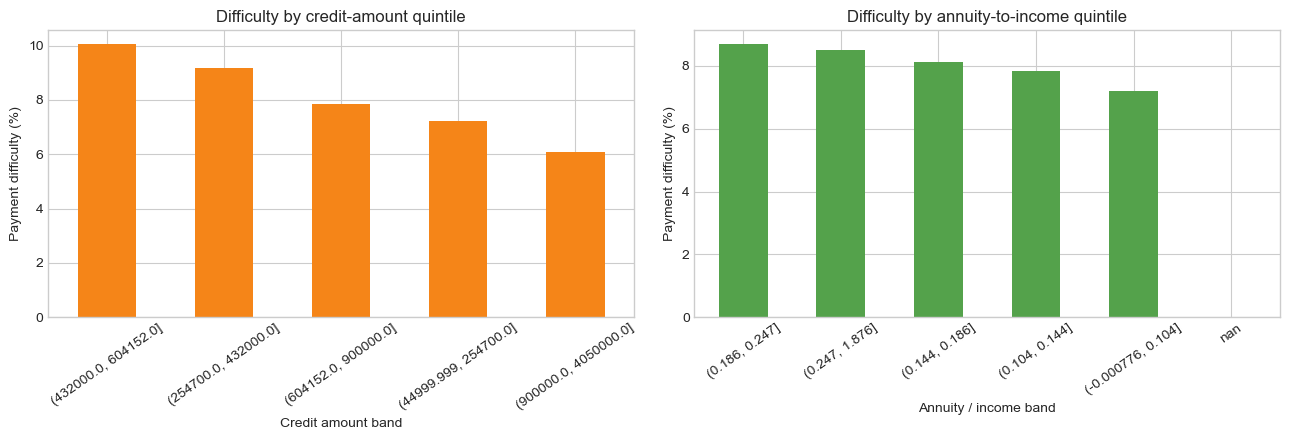

In [9]:
# Compare payment difficulty across equal-frequency credit and annuity-to-income bands.
burden = train.assign(
    credit_band=pd.qcut(train.AMT_CREDIT, 5, duplicates="drop"),
    annuity_income=train.AMT_ANNUITY / train.AMT_INCOME_TOTAL,
    annuity_income_band=pd.qcut(
        train.AMT_ANNUITY / train.AMT_INCOME_TOTAL, 5, duplicates="drop"
    ),
    loan_income_band=pd.qcut(
        train.AMT_CREDIT / train.AMT_INCOME_TOTAL, 4, duplicates="drop"
    ),
)
credit_rates = outcome_rates(burden, "credit_band")
annuity_income_rates = outcome_rates(burden, "annuity_income_band")
display(credit_rates)
display(annuity_income_rates)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
(credit_rates.difficulty_rate * 100).plot.bar(ax=axes[0], color="#F58518")
axes[0].set(
    title="Difficulty by credit-amount quintile",
    xlabel="Credit amount band",
    ylabel="Payment difficulty (%)",
)
(annuity_income_rates.difficulty_rate * 100).plot.bar(ax=axes[1], color="#54A24B")
axes[1].set(
    title="Difficulty by annuity-to-income quintile",
    xlabel="Annuity / income band",
    ylabel="Payment difficulty (%)",
)
for ax in axes:
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

Difficulty is not monotonic in credit amount: the middle credit bands have the highest rates (about 9.1%–10.1%), while the highest band is 6.1%. The upper annuity-to-income band is 8.5%, compared with 7.2% in the lowest band, but the middle bands overlap materially. That nonlinear pattern cautions against a simplistic “larger loan equals greater risk” rule. A later model should test transformed amount variables and interactions, then validate calibration by loan-size and burden segments.

### 8. Do employment-related values and missing occupation information need special treatment?

,applications,employment_sentinel_pct,occupation_missing_pct,difficulty_rate
age_band,,,,
"(20, 30]",45186,0.303,17.200,11.444
"(30, 40]",82349,0.610,16.428,9.590
"(40, 50]",76581,2.404,17.818,7.643
"(50, 60]",68109,34.528,45.314,6.120
"(60, 100]",35286,83.254,86.672,4.920


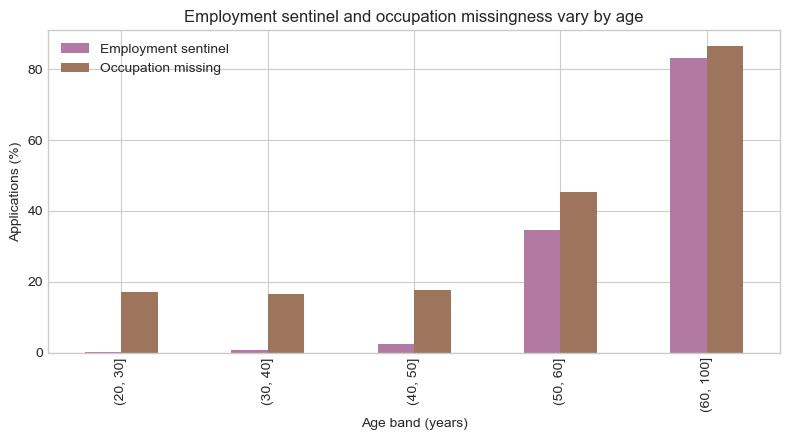

In [10]:
# Show employment-sentinel prevalence and occupation missingness by broad age band.
employment = train.assign(
    age_band=pd.cut(-train.DAYS_BIRTH / 365.25, [20, 30, 40, 50, 60, 100]),
    employment_sentinel=train.DAYS_EMPLOYED.eq(365243),
    occupation_missing=train.OCCUPATION_TYPE.isna(),
)
employment_summary = employment.groupby("age_band", observed=False).agg(
    applications=("TARGET", "size"),
    employment_sentinel_pct=("employment_sentinel", "mean"),
    occupation_missing_pct=("occupation_missing", "mean"),
    difficulty_rate=("TARGET", "mean"),
)
employment_summary[
    ["employment_sentinel_pct", "occupation_missing_pct", "difficulty_rate"]
] *= 100
display(employment_summary)

ax = employment_summary[["employment_sentinel_pct", "occupation_missing_pct"]].plot.bar(
    figsize=(8, 4.5), color=["#B279A2", "#9D755D"]
)
ax.set(
    title="Employment sentinel and occupation missingness vary by age",
    xlabel="Age band (years)",
    ylabel="Applications (%)",
)
ax.legend(["Employment sentinel", "Occupation missing"])
plt.tight_layout()
plt.show()

Occupation is missing for 96,391 applications (31.3%), and its missingness rises sharply in older age bands. The employment sentinel is also concentrated in older applicants, consistent with a status such as retirement rather than a literal employment duration. This reinforces two modeling decisions: preserve explicit missing/sentinel indicators, and evaluate whether models rely disproportionately on age-linked data availability. It would be inappropriate to interpret the sentinel as employment length or to infer a borrower’s occupation from the missing value.

### 9. Are process and contact flags useful risk signals or merely operational artifacts?

In [11]:
# Summarize common contact and document flags without labeling them as fraud evidence.
flag_cols = [c for c in train.columns if c.startswith("FLAG_DOCUMENT_")] + [
    "FLAG_EMP_PHONE",
    "FLAG_WORK_PHONE",
    "FLAG_PHONE",
    "FLAG_EMAIL",
    "FLAG_CONT_MOBILE",
]
flag_summary = pd.DataFrame(
    {
        "positive_count": [train[c].sum() for c in flag_cols],
        "positive_rate_pct": [
            train.groupby(c).TARGET.mean().get(1, np.nan) * 100 for c in flag_cols
        ],
        "negative_rate_pct": [
            train.groupby(c).TARGET.mean().get(0, np.nan) * 100 for c in flag_cols
        ],
    },
    index=flag_cols,
).sort_values("positive_count", ascending=False)
display(flag_summary.head(15))

,positive_count,positive_rate_pct,negative_rate_pct
FLAG_CONT_MOBILE,306937,8.073,7.840
FLAG_EMP_PHONE,252125,8.660,5.400
FLAG_DOCUMENT_3,218340,8.845,6.183
FLAG_PHONE,86431,7.036,8.478
FLAG_WORK_PHONE,61308,9.630,7.685
FLAG_DOCUMENT_6,27078,5.565,8.315
FLAG_DOCUMENT_8,25024,7.337,8.138
FLAG_EMAIL,17442,7.878,8.085
FLAG_DOCUMENT_5,4648,8.003,8.074
FLAG_DOCUMENT_16,3053,4.913,8.105


Several contact and document flags show different observed rates, but they are not evidence of fraud because this dataset contains no fraud label or verification-quality outcome. Their prevalence may reflect workflow, device access, document requirements, or operational practices. They should be treated as potentially unstable process features: document their business meaning, assess their stability by subgroup and—when timestamped data are available—by cohort, and prohibit any interpretation that a flag directly measures fraud or willingness to repay.

## Modeling, governance, and decision implications

### Candidate approach

The next stage should begin with a reproducible preprocessing-and-modeling pipeline:

1. Split the labeled applications before fitting any imputation, scaling, category encoding, outlier treatment, or resampling.
2. Benchmark a regularized logistic regression against a tree-based model that natively handles nonlinearities and missingness well.
3. Use cross-validation and a final untouched validation set. Select a deployment-representative split only after obtaining the missing timestamp and source-lineage information. Report ROC-AUC, precision-recall AUC, calibration, and performance at realistic review/approval thresholds.
4. Compare results by age band, gender, income type, housing type, missingness pattern, and loan size; add credit-history availability only after creating date-safe history definitions. Evaluate both performance and decision impact, not just overall AUC.
5. Convert model scores to decisions only after setting a documented risk appetite and incorporating the cost of default, pricing, funding, losses, operational review, and customer impact.

### Data limitations and governance

This file contains **issued loans only**. It cannot estimate rejection rates, rejected-applicant outcomes, approval-policy effects, or lending access. It also lacks current pricing, funding cost, loss-given-default, collections cost, and policy thresholds, so it cannot yet calculate financial value. The data do not provide an absolute application date suitable for calendar-cohort drift analysis. Finally, observed group gaps are associations in a selected historical portfolio, not proof of causal risk differences or fairness.

Before production use, the team needs documented as-of timestamps, source-system lineage, a holdout strategy that reflects deployment, calibration monitoring, adverse-impact testing, and human review/escalation rules for borderline cases.

## Results and next steps

This EDA confirms that payment difficulty is a relatively rare but material outcome (8.1%), so later evaluation must not rely on accuracy. The application tables have unique application keys and compatible feature schemas, but they contain meaningful data-quality issues: widespread and outcome-associated missingness, a large `DAYS_EMPLOYED = 365243` sentinel, rare category levels, and extreme income values. The defensible response is reversible preprocessing: retain raw columns, recode the employment sentinel to missing with an indicator, impute inside training folds, retain missingness indicators, and flag—not automatically remove—extremes.

Several associations merit modeling tests: younger age bands, some housing groups, occupation/income categories, missing building information, and affordability measures show different observed rates. None is sufficient for a rule or causal claim. The strongest change to the initial analytic approach is a shift from finding a single “high-risk” attribute to building and validating a calibrated multivariable model with careful missingness handling, subgroup monitoring, and explicit business-cost inputs.

The immediate next deliverables are a data-preparation plan, a modeling notebook with leakage-safe cross-validation, and a governance review of proxy features and disparate performance.

## AI-use statement

I used an AI assistant as a drafting and coding aid. It helped organize the EDA questions, suggest reproducible pandas and plotting patterns, and improve the wording of interpretations. I reviewed the assignment requirements, executed the analysis on the supplied files, checked the reported counts and rates, and revised the conclusions to distinguish descriptive associations from causal or policy claims. AI did not provide external data, make lending decisions, or replace my review of the output.